# Homework Assignment



> Oskar Krawczyk, AIML22 Group 3







---

In this homework assignment, we will focus on the topics covered during the week 3 of Lady Margaret Hall Summer Programme. This time, we will explore the field of self-supervised learning for computer vision, with an emphasis on CLIP models which will be compared with similar architectures, including DINO and DINOv2.

For the practical part of this task, we will work with [TinyImageNet](https://cs231n.stanford.edu/reports/2017/pdfs/930.pdf) dataset, which is a scaled-down version of the ImageNet dataset. Using this, we will evaluate CLIP's zero-shot classification performance. This will involve specific text prompts for each image class based on the dataset's words file and their text embeddings. We will then perform classification using similarily matching between the text and image embeddings, followed by evaluation and metrics analysis. Finally, we will implement the main task - Image Search Engine. We will build functionalities to search for relevant visual data using both text-to-image and image-to-image queries.


In the following notebook, I split my solution into six separate sections - Part 1, 2, 3, 4, 5, 6 - which follow the convention used in the initial [ImageSearch_Clip.ipynb](https://www.dropbox.com/scl/fi/5tchk22pf8zatb1on5fnf/Image_Search_with_CLIP.ipynb?rlkey=9jzl0on4chjdtnb8xlckmy2s2&st=hbfegt3d&e=1&dl=0) notebook. Each section includes the code as part of my solution as well as a brief explanation of certain concepts not mentioned during lectures/seminars. At the end of this notebook, I also denote resources used to complete and/or improve the final results and additional steps I have taken (beyond the required ones) to complete the notebook.


---



## Part 1

In this section we first import all necessary libraries into a single cell. The reason is that in the future if someone tries to access the very same code, it is preferable to keep it in the single cell instead of having imports scattered across the entire notebook. Then, we set up the notebook by specifying settings for plotting (matplotlib/seaborn), device and verify versions of libraries imported. Finally, we download the dataset to later explore its structure and content.

It is recommended you run the following cell since depending on the environment and settings, some packages might not be included in the standard setup (especially, tinyimagenet and transformers libraries). While debugging, removing -qq might be beneficial since this flag displays critical errors only.

In [ ]:
!pip -qq install tinyimagenet transformers

#### Library imports

In [33]:
import os
import tqdm
import random
import textwrap
import shutil

import numpy as np
import pandas as pd

import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from tinyimagenet import TinyImageNet
from transformers import CLIPModel, CLIPProcessor

from torch.utils.data import DataLoader
from PIL import Image

#### Notebook setup

Here, we configure the default settings for the notebook. First, we set the random seed to ensure the reproducibility of the results. Then, based on my preferences, we configure the default settings for matplotlib and seaborn packages to ensure consistent plotting. Finally, we display information regarding the imported libraries - if any methods change in the future versions of these packages, this is a reference point.

In [ ]:
SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 8)
sns.set_style("darkgrid")

print("---- Notebook setup info ----")
print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")
print(f"Torchvision:    {torchvision.__version__}")
print(f"Numpy:          {np.__version__}")
print(f"Pandas:         {pd.__version__}")

---- Notebook setup info ----
Device:         cuda
PyTorch:        2.11.0+cu128
Torchvision:    0.26.0+cu128
Numpy:          2.0.2
Pandas:         2.2.2


#### Explore the dataset

Now, we first download the TinyImageNet dataset, specifically using the validation split. Then, we first examine the sturcture of the dataset - its statistics, applied transformations and number of samples. Finally, we visualise five random samples with their corresponding labels.

In [ ]:
dataset = TinyImageNet("tiny-imagenet", split = "val")

100%|██████████| 248M/248M [00:11<00:00, 21.1MB/s]


In [ ]:
print("--------- Dataset information ---------\n")

print(f"Dataset root path: {dataset.root}\n")

print(f"Transformations: {dataset.transform}\n")

print(f"Statistics")
print(f"- Mean: {dataset.mean}")
print(f"- Std:  {dataset.std}\n")

print(f"Number of samples: {len(dataset)}\n")
print(f"Number of classes: {len(dataset.classes)}")

--------- Dataset information ---------

Dataset root path: tiny-imagenet/tiny-imagenet-200/val

Transformations: ToTensor()

Statistics
- Mean: [0.485, 0.456, 0.406]
- Std:  [0.229, 0.224, 0.225]

Number of samples: 10000

Number of classes: 200


As we can see, when loading TinyImageNet we only perform a standard transformation to a tensor and use exactly the same normalisation statistics as the original ImageNet. Furthermore, as the name "Tiny" suggests, the dataset is much smaller - it contains only 200 classes compared to ImageNet's 1000, the number of samples is reduced to 10000 with images of smaller resolution - 64x64.

Before me move on to visualising the samples, we will take a closer look at a single image from our dataset. First of all, we will make sure that its size is indeed 64x64, but I would especially like to draw attention to the label that can be assigned to a single image and what data type it is. This will be helpful in further analysis of the dataset, visualising the samples and eventually evaluating the model itself.

In [ ]:
single_sample = dataset[150]

print(f"--------- Sample image information ---------\n")
print(f"Image shape:        {list(single_sample[0].shape)}")
print(f"Class index:        {single_sample[1]}")
print(f"Class name(s):      {dataset.idx_to_words[single_sample[1]]}")

--------- Sample image information ---------

Image shape:        [3, 64, 64]
Class index:        3
Class name(s):      ['tailed frog', ' bell toad', ' ribbed toad', ' tailed toad', ' Ascaphus trui']


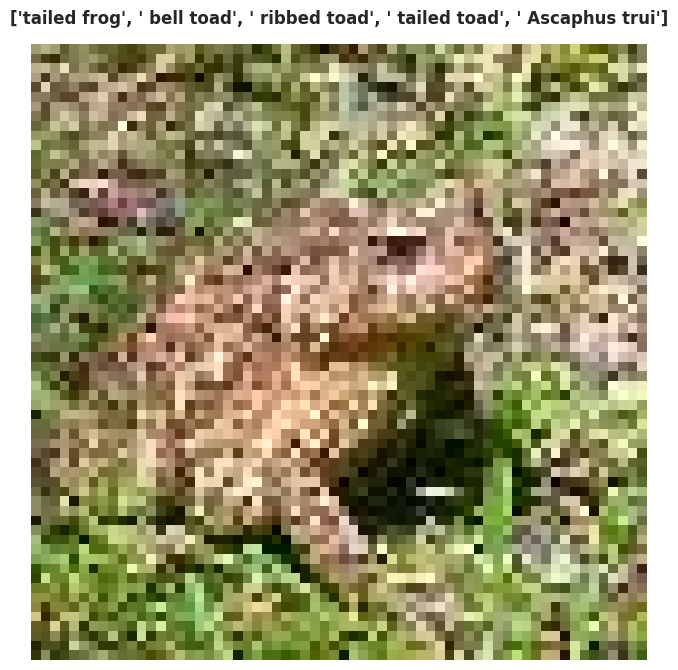

In [ ]:
image, label = single_sample

plt.imshow(image.permute(1, 2, 0))
plt.title(f"{dataset.idx_to_words[label]}", fontweight = "bold", pad = 15)
plt.axis("off")
plt.show()

As we can see, labels of the images in our dataset are of list type, in particular an image can have various labels assigned. On how to deal with it during evaluation, we will elaborate further in the upcoming sections, but for now in the visualisation below we will assume that the first two elements in the list will be our label (otherwise visualisation might be distorted).

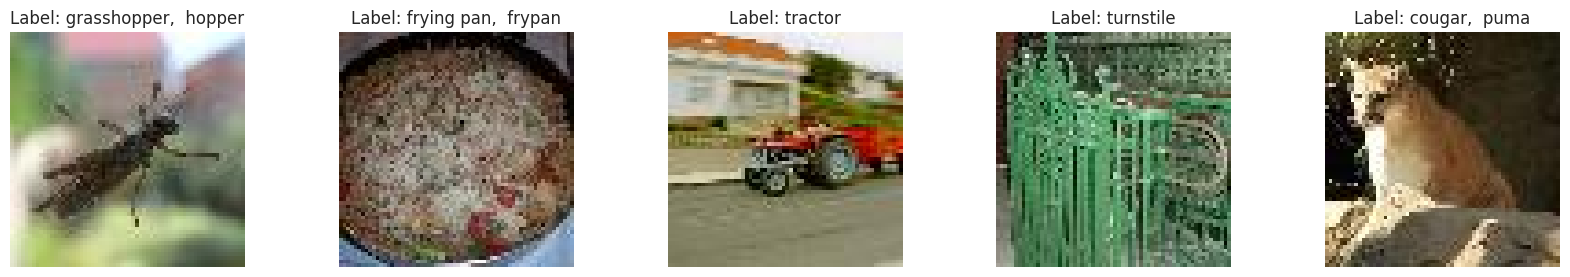

In [ ]:
NUM_SAMPLES = 5

random_indicies = [random.randint(0, len(dataset) - 1) for _ in range(NUM_SAMPLES)]

fig, axes = plt.subplots(nrows = 1, ncols = NUM_SAMPLES, figsize = (20, 4))
plt.subplots_adjust(wspace = .4)

for i in range(NUM_SAMPLES):
    image, label = dataset[random_indicies[i]]

    named_label = dataset.idx_to_words[label]
    label_str = ", ".join(named_label[:2])
    wrapped_label = "\n".join(textwrap.wrap(label_str, width = 25))

    axes[i].imshow(image.permute(1, 2, 0).cpu())
    axes[i].set_title(f"Label: {wrapped_label}")
    axes[i].axis("off")

## Part 2

In this section we will load the base model and preprocessor that we will be using throughout this notebook, namely [CLIP-ViT-base-patch32](https://huggingface.co/openai/clip-vit-base-patch32). Since the main building blocks of the CLIP architecture were covered in the lectures, we will only briefly discuss what characterises this architecture in particular. As the name suggests:



*   ViT - rather than a traditional convolutional neural network like ResNet, it uses Vision Transformer as its image encoder.
*   Patch 32 - before the image is fed into the ViT, it is divided into a grid of 32x32 pixels squares.


![CLIP Architecture](https://github.com/openai/CLIP/raw/main/CLIP.png)

For more details check [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020) paper.

In [ ]:
ARCHITECTURE = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"

model = CLIPModel.from_pretrained(ARCHITECTURE).to(device)
processor = CLIPProcessor.from_pretrained(ARCHITECTURE)

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.94GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/910 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

If you want to see the whole picture of the models, that is the architecture, layer by layer then uncomment the following line

**Note**: all layers with their parameters will be printed which might clutter the notebook (visually).

In [ ]:
# print(model)

Instead, we will by default display what the architecture of the models is and how many parameters it is since this will significantly determine the training phase in the following Part.

In [ ]:
model_parameters = sum(param.numel() for param in model.parameters())

print("------------- Model information -------------\n")

print(f"Architecture:           {ARCHITECTURE}\n")
print(f"Number of parameters:   {model_parameters:,}\n")

------------- Model information -------------

Architecture:           laion/CLIP-ViT-H-14-laion2B-s32B-b79K

Number of parameters:   986,109,441



## Part 3

In this section we define a function to extract and process CLIP embeddings for the entire dataset. First, we set up a dataloader to handle the batching efficiently - because TinyImageNet images are (what we saw in Part 1) 64x64 pixels and the pre-trained CLIP ViT-B32 model expects 224x224 inputs, we resize the image tensors before passing them directly to the model - Otherwise, the model's positional embeddings would fail to process the images correctly.

In [ ]:
@torch.no_grad()
def extract_embeddings(model, dataset, device, batch_size):
    '''
    Function to extract CLIP embeddings for the entire dataset.

    Args:
        model: CLIP model.
        dataset: TinyImageNet dataset.
        device: Device to run the model on.
        batch_size: Batch size for the dataloader.

    Returns:
        embeddings: Dictionary containing image and text embeddings.
    '''

    transformations = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(mean = dataset.mean, std = dataset.std)
    ])

    model.eval()

    loader = DataLoader(dataset, batch_size = batch_size, shuffle = False)

    embeddings, labels = [], []

    for images, label in tqdm.tqdm(loader, desc = "Extracting"):
        images = transformations(images).to(device)

        outputs = model.vision_model(pixel_values = images)
        pool = outputs.pooler_output

        embed = model.visual_projection(pool)
        embed = embed / embed.norm(dim = -1, keepdim = True, p = 2)

        embeddings.append(embed.cpu())

        labels.append(label)

    embeddings = torch.cat(embeddings, dim = 0)
    labels = torch.cat(labels, dim = 0)

    return {"embeddings": embeddings, "labels": labels}

In [ ]:
embeddings = extract_embeddings(model, dataset, device, batch_size = 128)

Extracting: 100%|██████████| 79/79 [18:54<00:00, 14.36s/it]


In [ ]:
embeddings_tensor = embeddings["embeddings"]
labels_tensor = embeddings["labels"]

In [ ]:
print("------------- Embedding information -------------\n")

print(f"Embeddings shape:           {list(embeddings_tensor.shape)}\n")
print(f"Labels shape:               {list(labels_tensor.shape)}\n")

torch.save(embeddings, "tinyimagenet_embeddings.pt")

------------- Embedding information -------------

Embeddings shape:           [10000, 1024]

Labels shape:               [10000]



As we can see, the extraction process was completed successfully. It is worth noting that the primary reason for performing such extraction is to translate the raw images provided in the dataset into a shared latent space. This step is the backbone of the search engine - it will allow us to efficiently retrieve images in the upcoming sections by comparing them against text or image queries using a simple tools to measure similarity.

## Part 4

DESC


#### First approach

In [ ]:
words_path = os.path.join("tiny-imagenet/tiny-imagenet-200", "words.txt")

words_dict = {}
with open(words_path, "r") as file:
    for line in file:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            word, idx = parts
            words_dict[idx] = idx.split(",")[0].strip()

In [ ]:
prompts = []
for i in range(len(dataset.classes)):
    eng = dataset.idx_to_words[i][0].strip()
    prompts.append(f"a photo of a {eng}")

text_in = processor(text = prompts, return_tensors = "pt", padding = True).to(device)
model.eval()

with torch.no_grad():
    text_embed = model.text_model(**text_in)
    pool = text_embed.pooler_output
    text_embed = model.text_projection(pool)
    text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)
    text_embed = text_embed.cpu()

similarities = torch.matmul(embeddings_tensor, text_embed.T)
preds = similarities.argmax(dim = 1)

accuracy = (preds == labels_tensor).float().mean().item()

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 76.46%


#### Second approach

In [ ]:
templates = [
    'a bad photo of a {}.',
    'a photo of many {}.',
    'a sculpture of a {}.',
    'a photo of the hard to see {}.',
    'a low resolution photo of the {}.',
    'a rendering of a {}.',
    'graffiti of a {}.',
    'a bad photo of the {}.',
    'a cropped photo of the {}.',
    'a tattoo of a {}.',
    'the embroidered {}.',
    'a photo of a hard to see {}.',
    'a bright photo of a {}.',
    'a photo of a clean {}.',
    'a photo of a dirty {}.',
    'a dark photo of the {}.',
    'a drawing of a {}.',
    'a photo of my {}.',
    'the plastic {}.',
    'a photo of the cool {}.',
    'a close-up photo of a {}.',
    'a black and white photo of a {}.',
    'a painting of the {}.',
    'a painting of a {}.',
    'a pixelated photo of the {}.',
    'a sculpture of the {}.',
    'a bright photo of the {}.',
    'a cropped photo of a {}.',
    'a plastic {}.',
    'a photo of the dirty {}.',
    'a jpeg corrupted photo of a {}.',
    'a blurry photo of the {}.',
    'a photo of the {}.',
    'a good photo of the {}.',
    'a rendering of the {}.',
    'a {} in a video game.',
    'a photo of one {}.',
    'a doodle of a {}.',
    'a close-up photo of the {}.',
    'a photo of a {}.',
    'the origami {}.',
    'the {} in a video game.',
    'a sketch of a {}.',
    'a doodle of the {}.',
    'a origami {}.',
    'a low resolution photo of a {}.',
    'the toy {}.',
    'a photo of the clean {}.',
    'a photo of a large {}.',
    'a photo of a nice {}.',
    'a photo of a weird {}.',
    'a photo of the weird {}.',
    'a sketch of the {}.',
    'a tattoo of the {}.',
    'a photo of a cool {}.',
    'a photo of a small {}.',
    'a photo of the large {}.',
    'a black and white photo of the {}.',
    'a drawing of the {}.',
    'a photo of the nice {}.',
    'a photo of the small {}.',
    'a photo of a strange {}.',
    'a photo of the strange {}.',
    'a jpeg corrupted photo of the {}.',
    'a good photo of a {}.',
    'a photo of the nice {}.',
    'a a photo of the large {}.',
    'a photo of the small {}.',
    'a photo of a weird {}.'
]

model.eval()
weights = []

with torch.no_grad():
    for i in tqdm.tqdm(range(len(dataset.classes))):
        class_names = [name.strip() for name in dataset.idx_to_words[i]]

        class_embeds = []
        for class_name in class_names:
            prompts = [template.format(class_name) for template in templates]
            text_in = processor(text = prompts, return_tensors = "pt", padding = True).to(device)

            text_embed = model.text_model(**text_in)
            pool = text_embed.pooler_output
            text_embed = model.text_projection(pool)
            text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)

            class_embeds.append(text_embed)

        class_embeds = torch.cat(class_embeds, dim = 0)
        class_embeds = class_embeds.mean(dim = 0)

        class_embeds = class_embeds / class_embeds.norm(dim = -1, keepdim = True, p = 2)
        weights.append(class_embeds.cpu())

text_embed = torch.stack(weights, dim = 0)
similarities = torch.matmul(embeddings_tensor, text_embed.T)
preds = similarities.argmax(dim = 1)

accuracy = (preds == labels_tensor).float().mean().item()

print(f"Accuracy: {accuracy * 100:.2f}%")

100%|██████████| 200/200 [01:28<00:00,  2.27it/s]

Accuracy: 77.50%


## Part 5

DESC

In [ ]:
transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean = dataset.mean, std = dataset.std)
])

In [ ]:
def text_image(query, model, processor, device, image_embedding, k = 5):
    model.eval()

    with torch.no_grad():
        text = processor(text = [query], return_tensors = "pt", padding = True).to(device)
        text_embed = model.text_model(**text)
        text_embed = model.text_projection(text_embed.pooler_output)

        text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)
        text_embed = text_embed.cpu()

        similarities = torch.matmul(image_embedding, text_embed.T).squeeze()
        topk_scores, topk_indices = torch.topk(similarities, k = k)

    return topk_scores, topk_indices

In [ ]:
def image_image(query, model, device, image_embedding, k = 5):
    model.eval()

    with torch.no_grad():
        query = transformations(query).unsqueeze(0).to(device)
        query_embed = model.vision_model(pixel_values = query)
        query_embed = model.visual_projection(query_embed.pooler_output)

        query_embed = query_embed / query_embed.norm(dim = -1, keepdim = True, p = 2)
        query_embed = query_embed.cpu()

        similarities = torch.matmul(image_embedding, query_embed.T).squeeze()
        topk_scores, topk_indices = torch.topk(similarities, k = k)

    return topk_scores, topk_indices

In [ ]:
def visualise_search(dataset, topk_scores, topk_indices, query_txt = None, query_img = None):
    k = len(topk_indices)

    num_cols = k + 1 if query_img is not None else k

    fig, axes = plt.subplots(nrows = 1, ncols = num_cols, figsize = (20, 4))
    plt.subplots_adjust(wspace = .4)

    offset = 0

    if query_img is not None:
        axes[0].imshow(query_img.permute(1, 2, 0).cpu())
        axes[0].set_title(f"Query: {query_txt}", fontweight = "bold", pad = 15)
        axes[0].axis("off")
        offset = 1

    if query_txt is not None:
        axes[0].set_title(f"Query: {query_txt}", fontweight = "bold", pad = 15)

    for i in range(k):
        idx = topk_indices[i]
        score = topk_scores[i]

        image, label = dataset[idx]

        label_name = dataset.idx_to_words[label][0].strip()
        wrapped_label = "\n".join(textwrap.wrap(label_name, width = 25))

        axes[i + offset].imshow(image.permute(1, 2, 0).cpu())
        axes[i + offset].set_title(f"Label: {wrapped_label}\nScore: {score:.4f}", fontweight = "bold", pad = 15)
        axes[i + offset].axis("off")

    plt.tight_layout()
    plt.show()

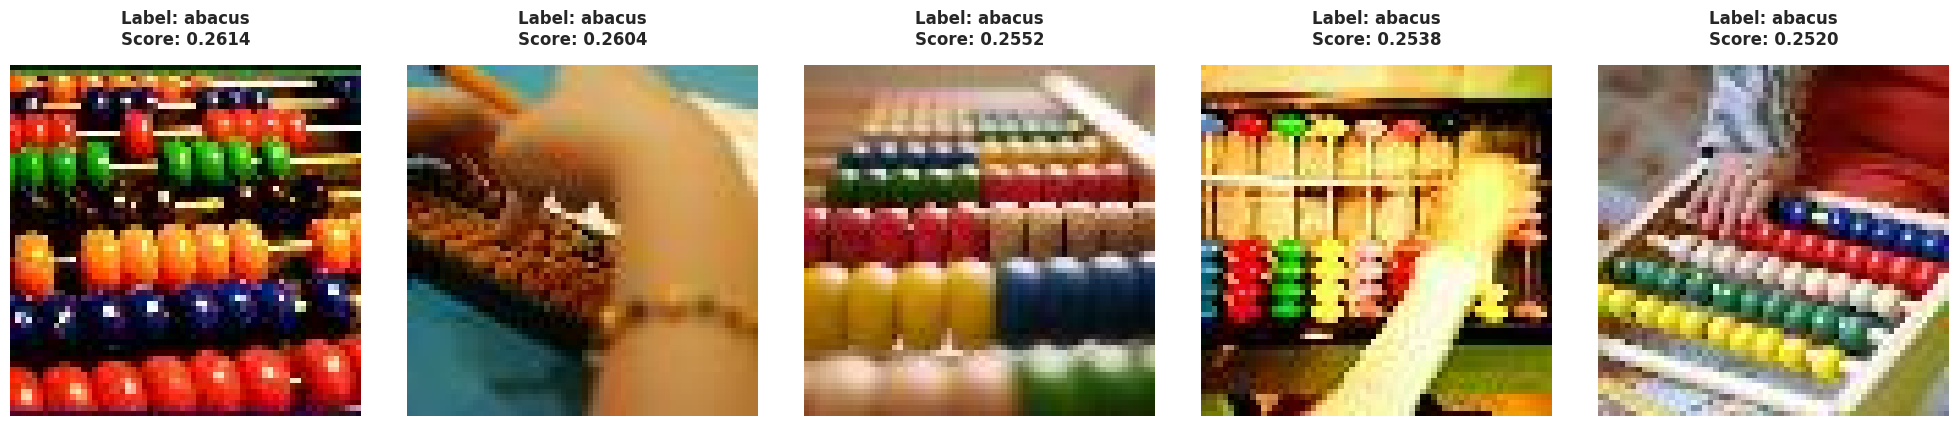

In [ ]:
text_query = "Mathematics"
scores, indices = text_image(text_query, model, processor, device, embeddings_tensor)

visualise_search(dataset, scores, indices, query_txt = text_query)

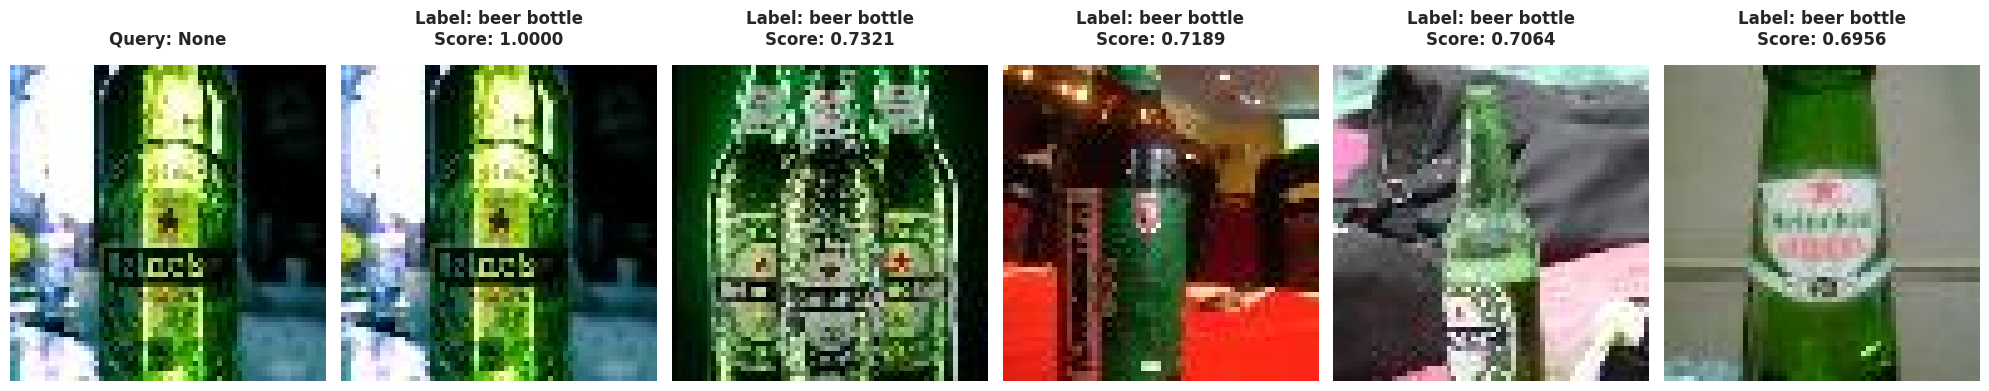

In [ ]:
query_index = random.randint(0, len(dataset) - 1)
query_image, query_label = dataset[query_index]

scores, indices = image_image(query_image, model, device, embeddings_tensor)

visualise_search(dataset, scores, indices, query_img = query_image)

## Part 6

DESC

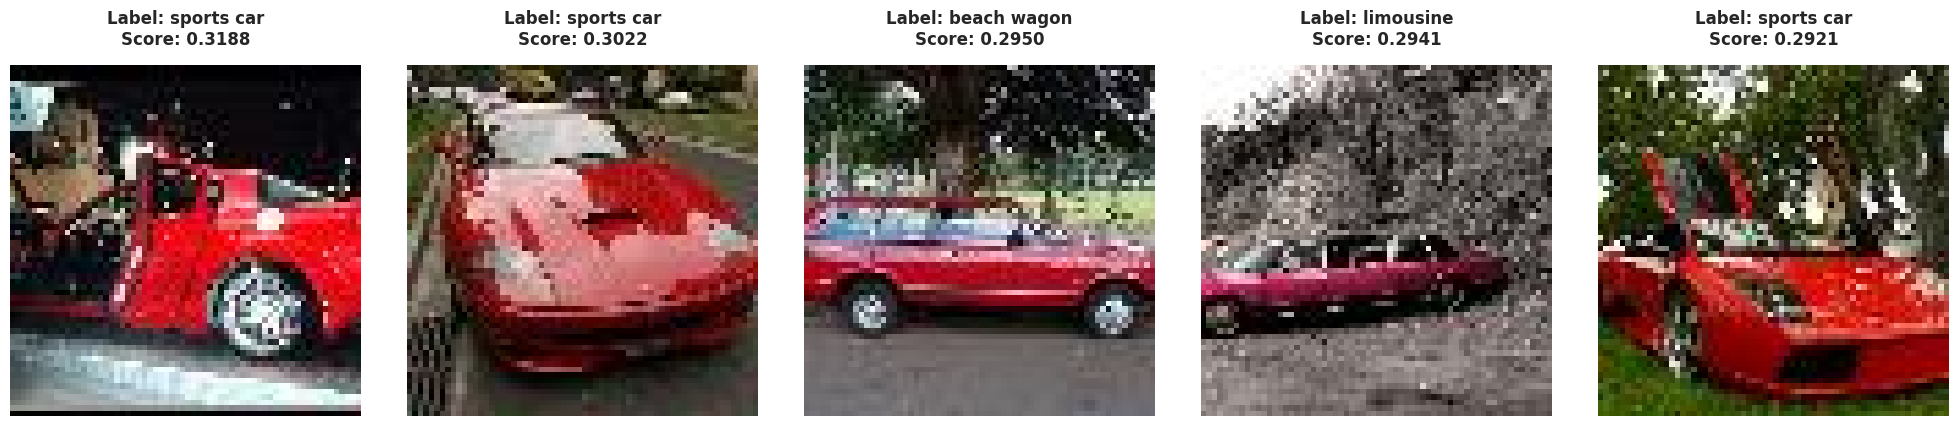

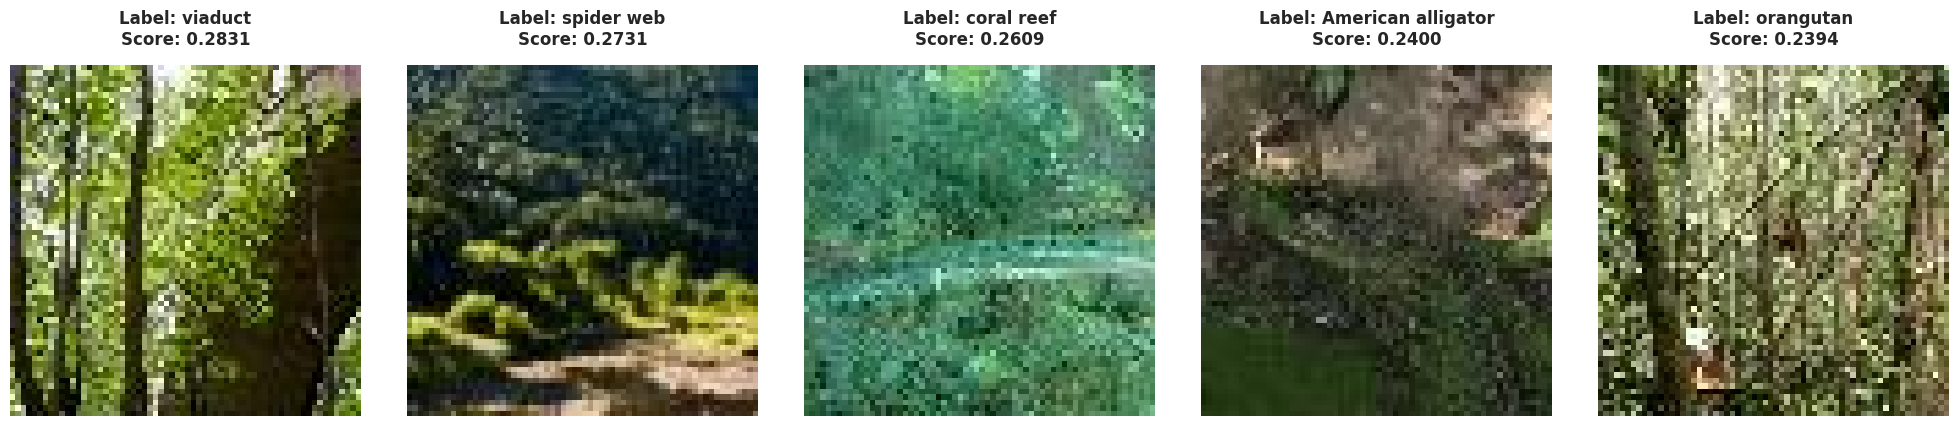

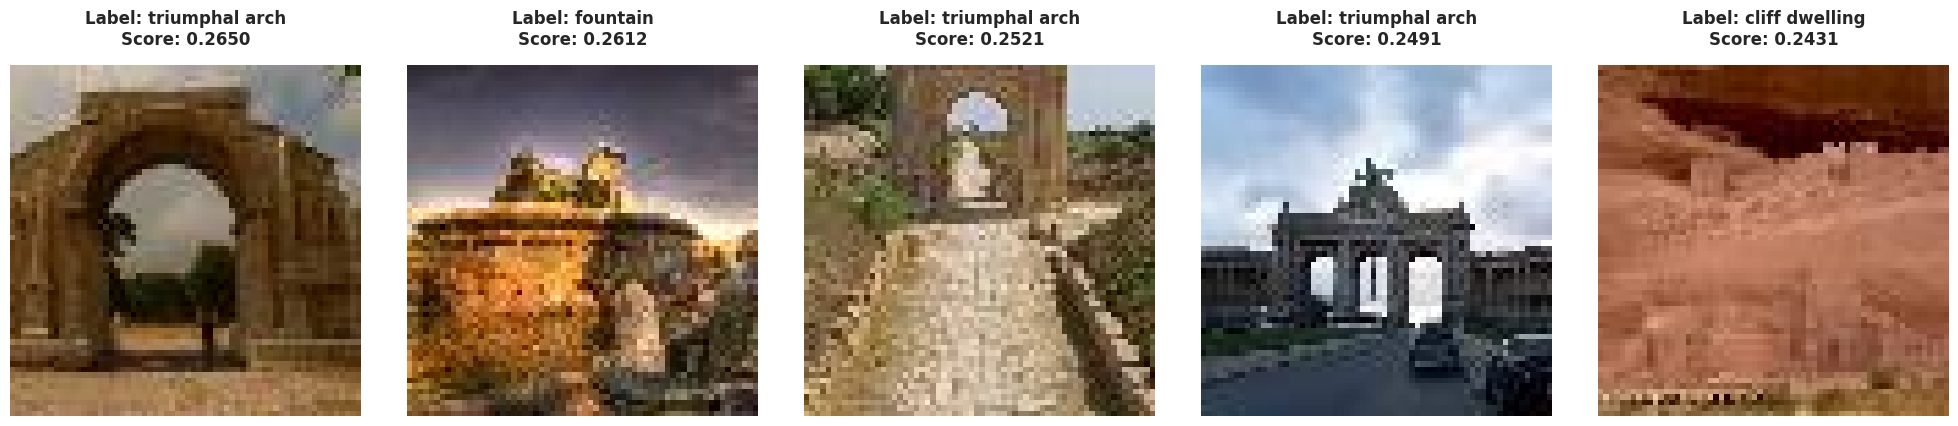

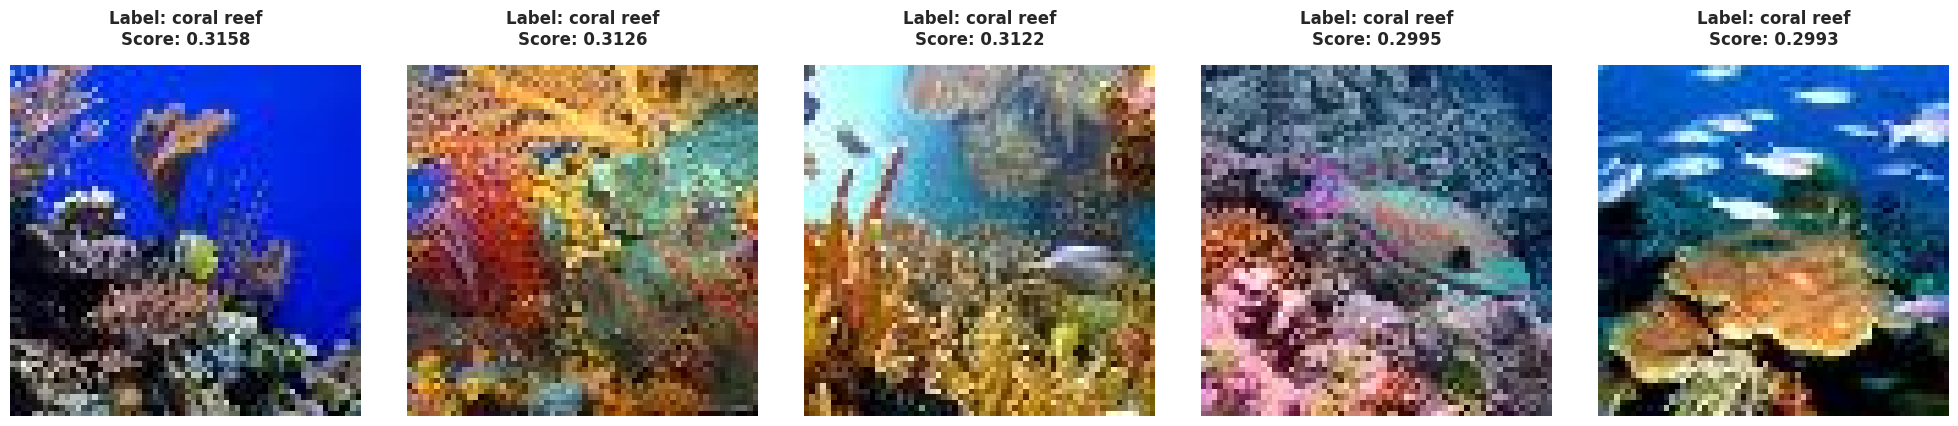

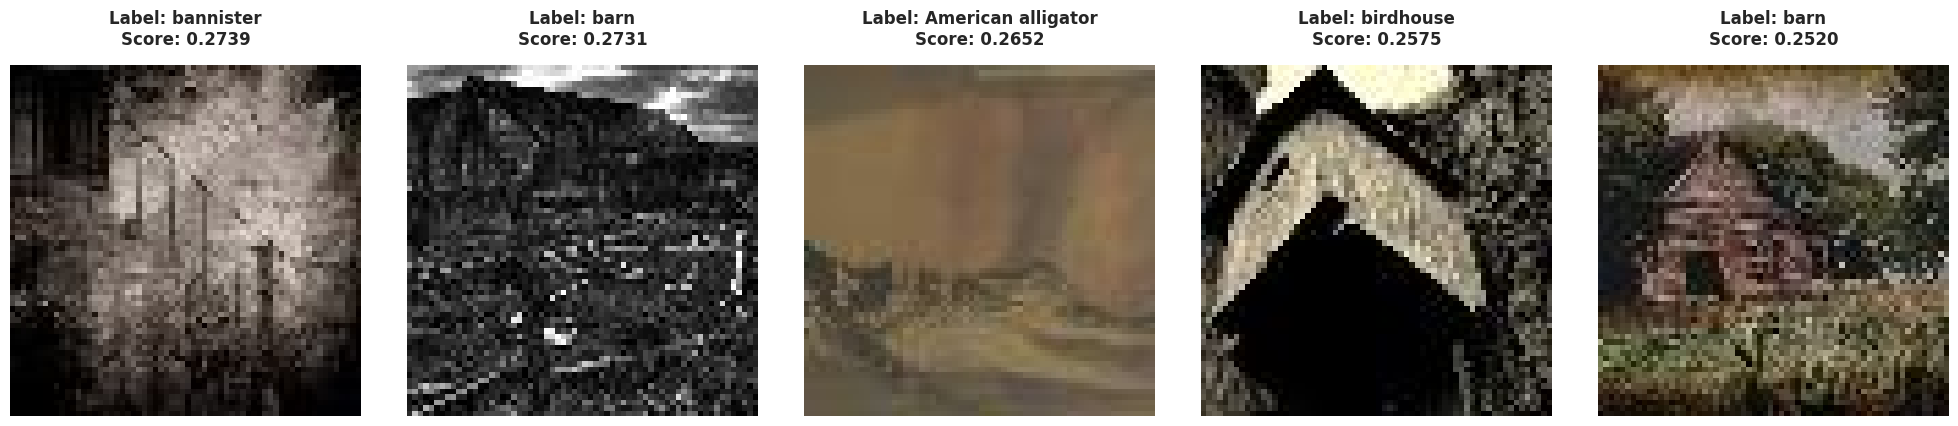

In [42]:
sample_queries = [
    "A red car",
    "A beautiful green forest",
    "A beautiful ancient city",
    "A colourful coral reef",
    "A dark spooky village"
]

for q in sample_queries:
    scores, indices = text_image(q, model, processor, device, embeddings_tensor)
    visualise_search(dataset, scores, indices, query_txt = q)

In [38]:
repo_url = "https://github.com/OskarK16/LMH-Tutorials.git"
repo_dir = "LMH-Tutorials"

if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)

In [39]:
!git clone {repo_url}

Cloning into 'LMH-Tutorials'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 58 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 11.77 MiB | 8.57 MiB/s, done.
Resolving deltas: 100% (20/20), done.


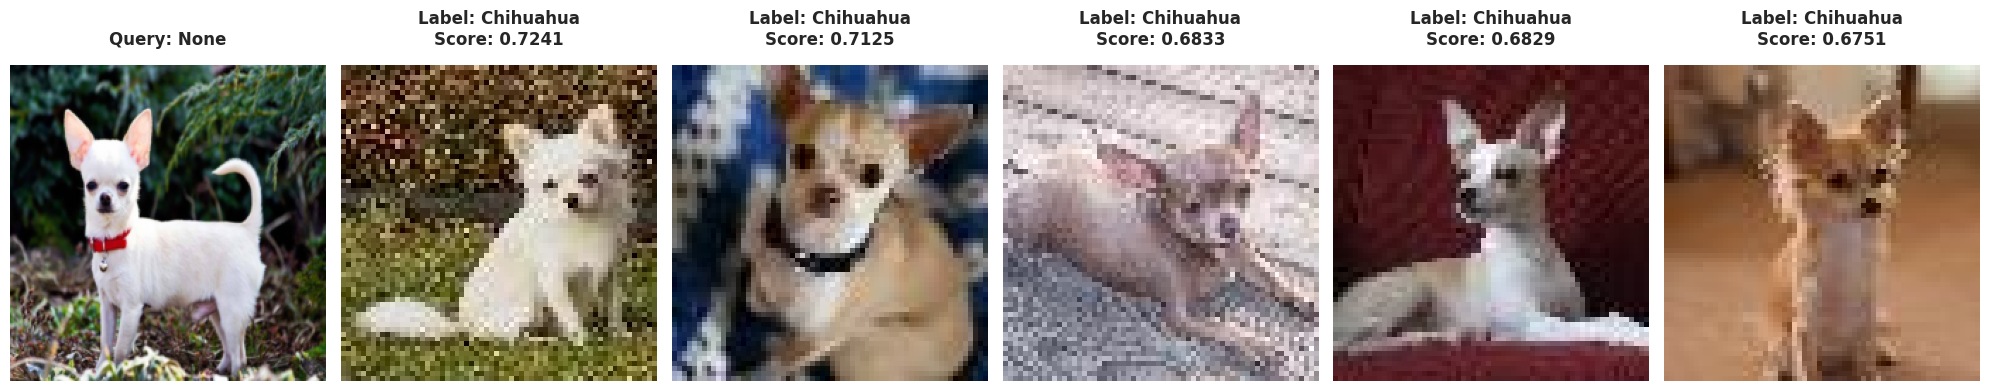

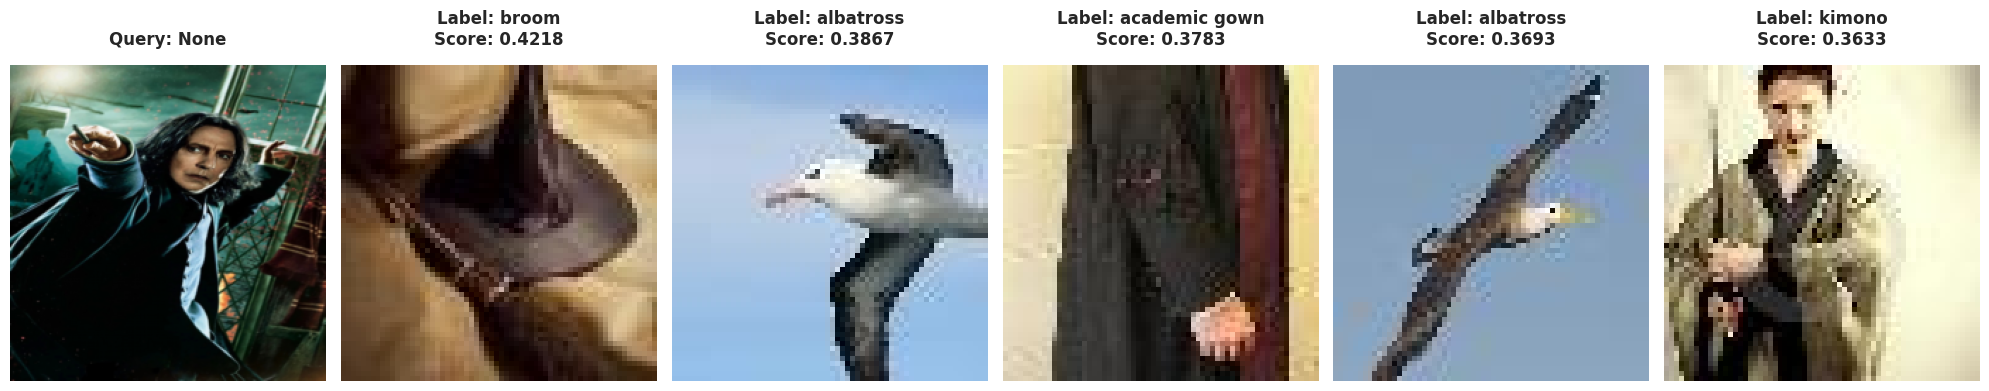

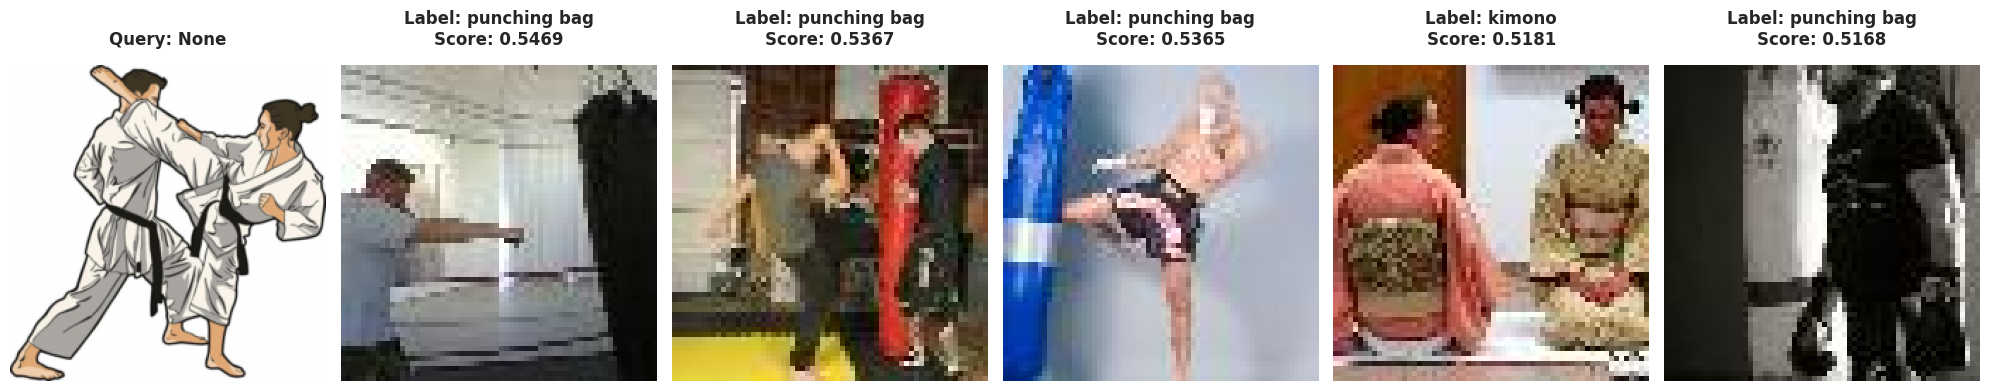

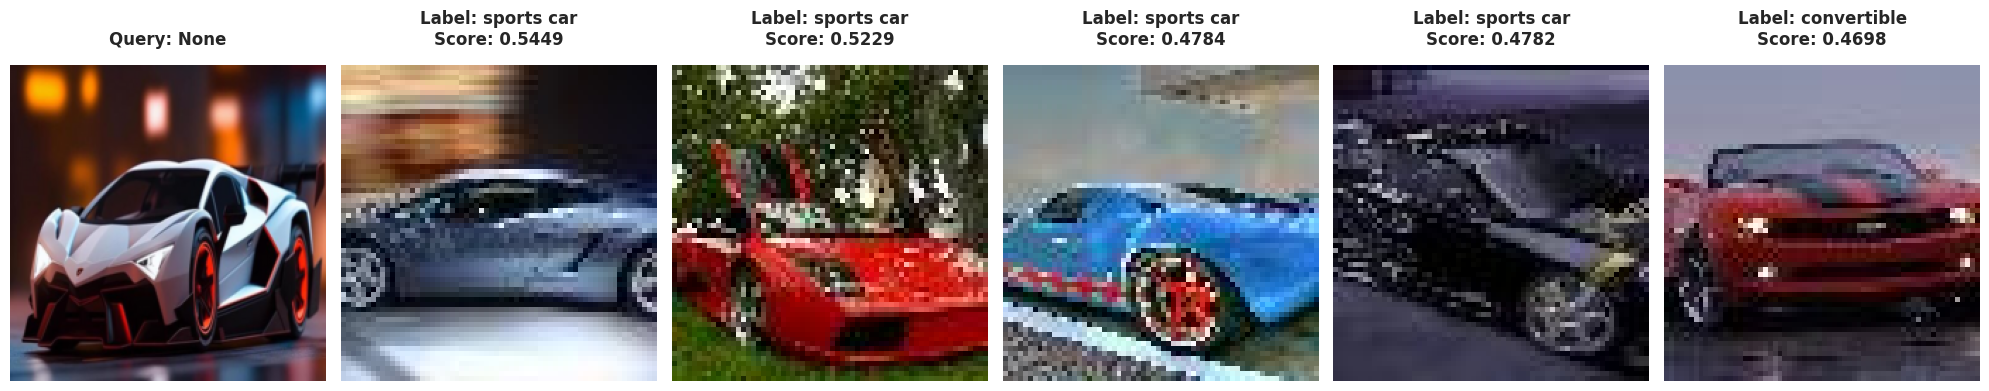

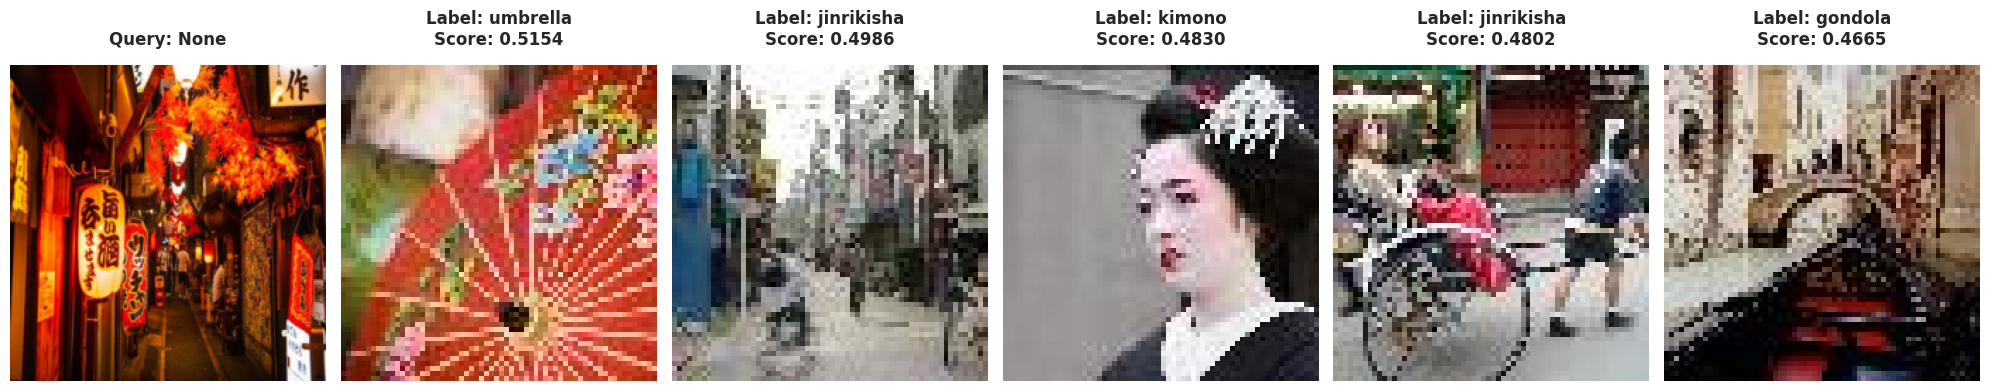

In [40]:
image_paths = [f"{repo_dir}/images/image{i}.jpg" for i in range(1, 6)]
source_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

for path in image_paths:
    name = os.path.basename(path)

    if not os.path.exists(path):
        print("File not found\n")
        continue

    image = Image.open(path).convert("RGB")
    image_tensor = transforms.ToTensor()(image)
    image_tensor = source_image_transform(image_tensor)

    scores, indices = image_image(image_tensor, model, device, embeddings_tensor)
    visualise_search(dataset, scores, indices, query_img = image_tensor)

## References



*   CLIP original paper: https://arxiv.org/pdf/2103.00020
*   List item



---





logo_lg.svg